# Master Results Notebook for Paper Production

This notebook serves as the primary driver for generating the final, publication-quality figures and tables for the paper. It leverages the consolidated logic in `src/sed_pipeline/` to ensure zero data loss and reproducible results.

In [14]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

# Ensure the project root is in the path to import the local package
sys.path.append(os.path.abspath('..'))

from src.sed_pipeline import config, data_io, composite_math, photometry, visualization, analysis

# PASA publication styling
plt.style.use('default')
visualization.apply_pasa_style()
os.makedirs(config.PROCESSED_DATA_DIR, exist_ok=True)

## 1. Load Configurations and Base Models

We start by loading the necessary filters (UVJ, ugr, IRAC) and the base Type 1 and Type 2 AGN SKIRTOR models using parameters defined in the thesis methodology.

In [15]:
# Load Filters
filters = photometry.load_passbands(config.FILTER_PATHS)

# Set specific paths for templates
skirtor_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'Skirtor')
brown_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'Brown', '2014', 'Rest')

# Load AGN Models
agn_type1 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE1_PARAMS)
agn_type2 = data_io.read_skirtor_model(skirtor_dir, **config.SKIRTOR_TYPE2_PARAMS)

# Load GALSEDATLAS (Brown) Templates
brown_templates, brown_names = data_io.read_brown_galaxy_templates(brown_dir)

## 2. Generate Composite SEDs and Calculate Colours

We will iterate over the alpha values, calculate composite SEDs for all templates and both AGN types, and compute their colours. For `ugr` and `IRAC` diagrams, specific artificial redshifting is applied to reflect survey selections.

In [16]:
results = []
alphas = config.ALPHA_VALUES

# Target redshifts for artificial redshifting
z_ugr = 3.0 # Within the U-dropout target range of 2.6 < z < 3.6
z_irac = 0.0 # Restframe for standard Lacy wedge demo

for t_idx, gal_sed in enumerate(brown_templates):
    gal_name = brown_names[t_idx]
    print(f"Processing template {t_idx+1}/{len(brown_templates)}: {gal_name}")
    
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            
            # Calculate UVJ (restframe)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            
            # Calculate ugr (redshifted to z=3.0)
            ug, gr = photometry.calculate_ugr_colours(comp_sed, filters['u'], filters['g'], filters['r'], redshift=z_ugr)
            
            # Calculate IRAC (restframe)
            f5836, f8045 = photometry.calculate_irac_colours(comp_sed, filters['3.6'], filters['4.5'], filters['5.8'], filters['8.0'], redshift=z_irac)
            
            results.append({
                'Template': gal_name,
                'AGN_Type': agn_name,
                'Alpha': alpha,
                'U-V': uv,
                'V-J': vj,
                'u-g': ug,
                'g-r': gr,
                'f5836': f5836,
                'f8045': f8045
            })

df_results = pd.DataFrame(results)
print("Processed all composite combinations.")

Processing template 1/128: Arp_118
Processing template 2/128: Arp_256_N
Processing template 3/128: Arp_256_S
Processing template 4/128: CGCG_049-057
Processing template 5/128: CGCG_436-030
Processing template 6/128: CGCG_453-062
Processing template 7/128: Haro_06
Processing template 8/128: IC_0691
Processing template 9/128: IC_0860
Processing template 10/128: IC_0883
Processing template 11/128: IC_4051
Processing template 12/128: IC_4553
Processing template 13/128: IC_5298
Processing template 14/128: III_Zw_035
Processing template 15/128: II_Zw_096
Processing template 16/128: IRAS_08572+3915
Processing template 17/128: IRAS_17208-0014
Processing template 18/128: Mrk_0331
Processing template 19/128: Mrk_0475
Processing template 20/128: Mrk_0930
Processing template 21/128: Mrk_1450
Processing template 22/128: Mrk_1490
Processing template 23/128: Mrk_33
Processing template 24/128: NGC_0337
Processing template 25/128: NGC_0474
Processing template 26/128: NGC_0520
Processing template 27/128

## 3. Colour Evolution Evolution Plots

These plots show how individual galaxies move through colour-colour space as the AGN contribution ($\alpha$) increases from 0 to 1.

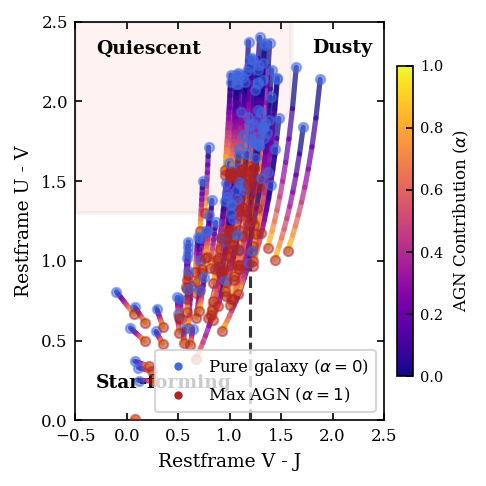

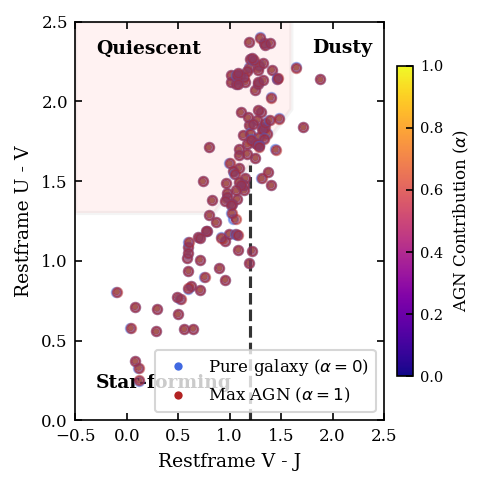

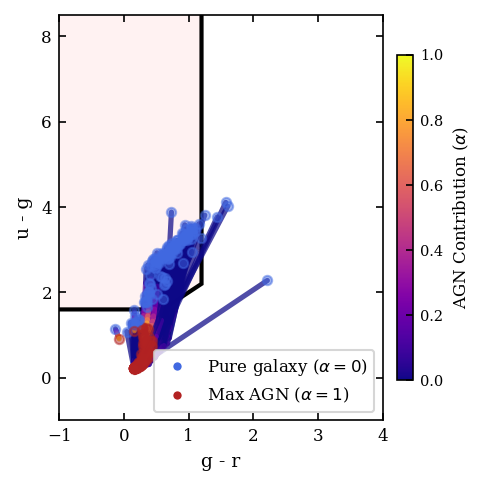

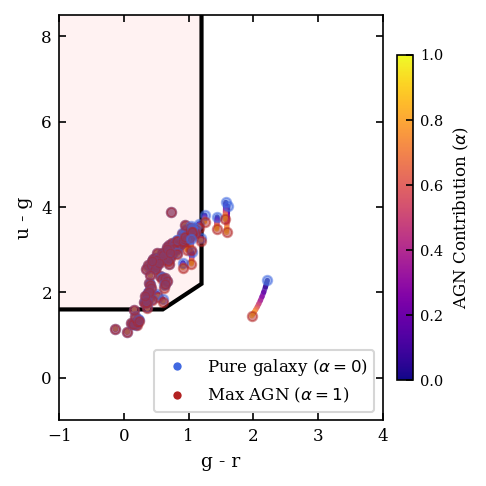

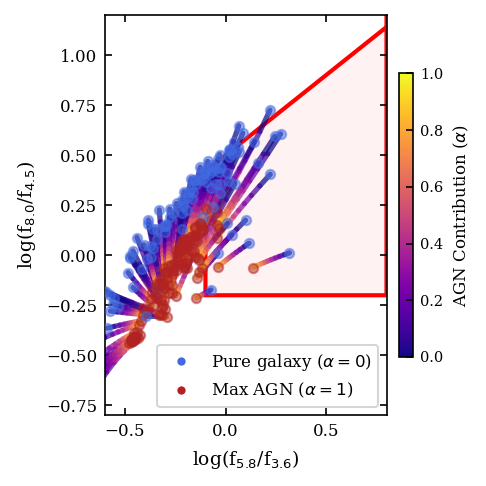

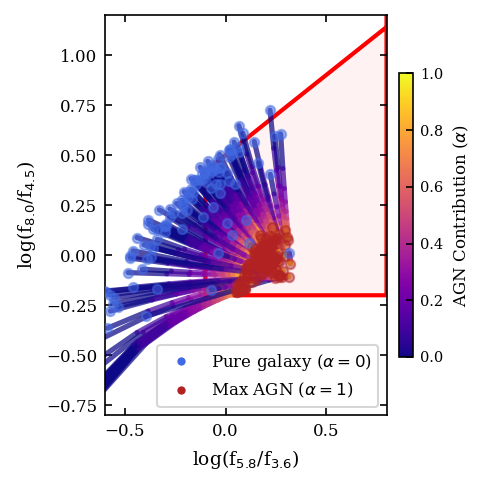

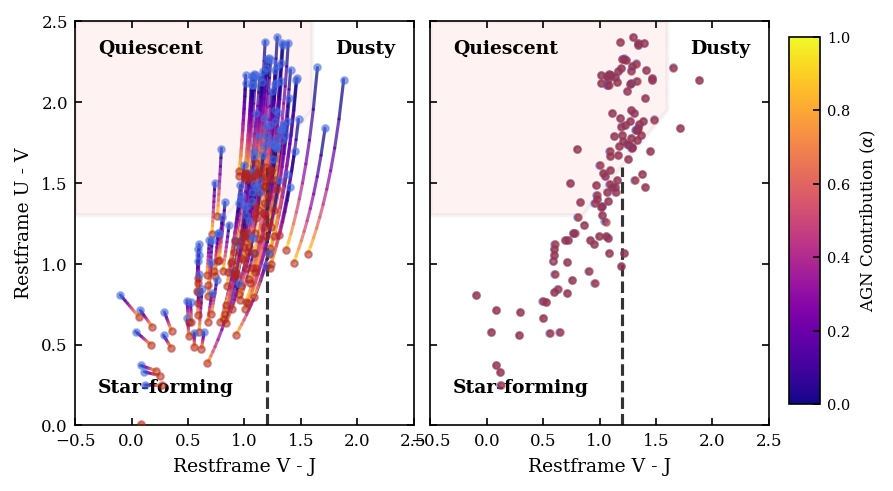

In [17]:
def plot_evolution_tracks(df, agn_type, x_col, y_col, plot_func, title, output_name):
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    subset = df[df['AGN_Type'] == agn_type]

    cmap = plt.cm.plasma
    norm = plt.Normalize(vmin=0, vmax=1)

    for template in subset['Template'].unique():
        temp_df = subset[subset['Template'] == template].sort_values('Alpha')
        xs = temp_df[x_col].values
        ys = temp_df[y_col].values
        for i in range(len(temp_df) - 1):
            ax.plot(xs[i:i+2], ys[i:i+2],
                    color=cmap(norm(temp_df['Alpha'].iloc[i])),
                    linewidth=2.5, alpha=0.72, solid_capstyle='round')
        ax.scatter(xs[0],  ys[0],  color='royalblue', s=20, zorder=5, alpha=0.5)
        ax.scatter(xs[-1], ys[-1], color='firebrick',  s=20, zorder=5, alpha=0.5)

    plot_func([], [], ax=ax, title=title)

    custom_lines = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='royalblue', markersize=5, label=r'Pure galaxy ($\alpha=0$)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='firebrick',  markersize=5, label=r'Max AGN ($\alpha=1$)'),
    ]
    ax.legend(handles=custom_lines, loc='lower right')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'AGN Contribution ($\alpha$)', fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, output_name), dpi=300, bbox_inches='tight')
    return fig, ax

plot_evolution_tracks(df_results, 'Type1', 'V-J', 'U-V', visualization.plot_uvj_diagram,
                      '', 'Paper_UVJ_Evolution_Type1.pdf')
plot_evolution_tracks(df_results, 'Type2', 'V-J', 'U-V', visualization.plot_uvj_diagram,
                      '', 'Paper_UVJ_Evolution_Type2.pdf')

plot_evolution_tracks(df_results, 'Type1', 'g-r', 'u-g', visualization.plot_ugr_diagram,
                      '', 'Paper_ugr_Evolution_Type1.pdf')
plot_evolution_tracks(df_results, 'Type2', 'g-r', 'u-g', visualization.plot_ugr_diagram,
                      '', 'Paper_ugr_Evolution_Type2.pdf')

plot_evolution_tracks(df_results, 'Type1', 'f5836', 'f8045', visualization.plot_irac_diagram,
                      '', 'Paper_IRAC_Evolution_Type1.pdf')
plot_evolution_tracks(df_results, 'Type2', 'f5836', 'f8045', visualization.plot_irac_diagram,
                      '', 'Paper_IRAC_Evolution_Type2.pdf')

# --- Combined UVJ evolution: Type 1 left, Type 2 right, shared y-axis ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=visualization.PASA_WIDE, sharey=True)
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=0, vmax=1)

for ax, agn_type in [(ax1, 'Type1'), (ax2, 'Type2')]:
    subset = df_results[df_results['AGN_Type'] == agn_type]
    for template in subset['Template'].unique():
        temp_df = subset[subset['Template'] == template].sort_values('Alpha')
        xs, ys = temp_df['V-J'].values, temp_df['U-V'].values
        for i in range(len(temp_df) - 1):
            ax.plot(xs[i:i+2], ys[i:i+2], color=cmap(norm(temp_df['Alpha'].iloc[i])),
                    linewidth=1.5, alpha=0.72, solid_capstyle='round')
        ax.scatter(xs[0],  ys[0],  color='royalblue', s=10, zorder=5, alpha=0.5)
        ax.scatter(xs[-1], ys[-1], color='firebrick',  s=10, zorder=5, alpha=0.5)
    visualization.plot_uvj_diagram([], [], ax=ax, title='')

# ax1.text(0.04, 0.97, 'Type 1 AGN', transform=ax1.transAxes, fontsize=8, va='top', fontweight='bold')
# ax2.text(0.04, 0.97, 'Type 2 AGN', transform=ax2.transAxes, fontsize=8, va='top', fontweight='bold')
ax2.set_ylabel('')

custom_lines = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='royalblue', markersize=5, label=r'Pure galaxy ($\alpha=0$)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='firebrick',  markersize=5, label=r'Max AGN ($\alpha=1$)'),
]
# ax1.legend(handles=custom_lines, loc='lower right', fontsize=7)
leg2 = ax2.get_legend()
if leg2 is not None:
    leg2.remove()

fig.subplots_adjust(wspace=0.05, right=0.80)
cbar_ax = fig.add_axes([0.82, 0.15, 0.03, 0.70])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r'AGN Contribution ($\alpha$)', fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_UVJ_Evolution_Combined.pdf'), dpi=300, bbox_inches='tight')
plt.show()

## 3b. SWIRE Template Evolution (Fig 3)

Generating initial composite modelling using the SWIRE template library.

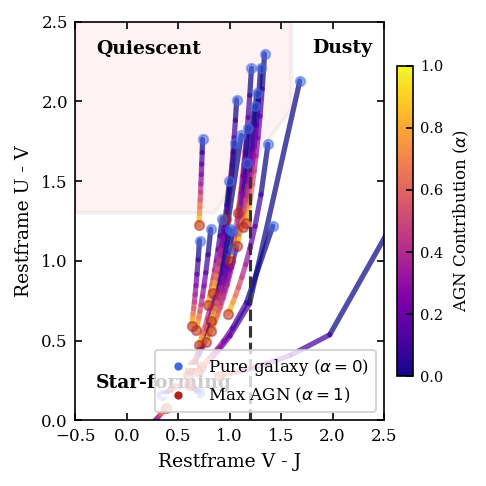

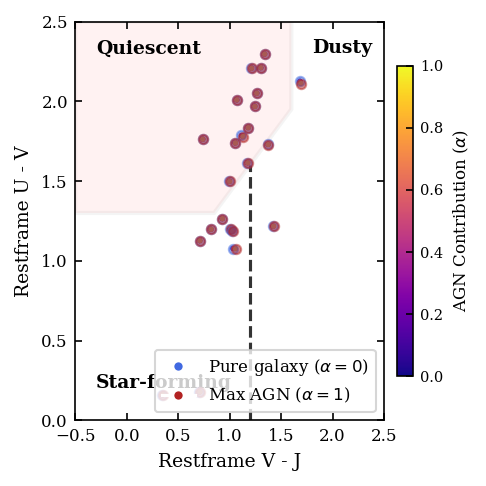

In [18]:
# Load SWIRE Templates
swire_dir = os.path.join(config.RAW_DATA_DIR, 'Templates', 'SWIRE')
swire_templates, swire_names = data_io.read_swire_templates(swire_dir)

swire_results = []

for t_idx, gal_sed in enumerate(swire_templates):
    gal_name = swire_names[t_idx]
    for agn_name, agn_model in [('Type1', agn_type1), ('Type2', agn_type2)]:
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_model, gal_sed, alpha)
            uv, vj = photometry.calculate_UVJ_colours(comp_sed, filters['U'], filters['V'], filters['J'])
            swire_results.append({'Template': gal_name, 'AGN_Type': agn_name, 'Alpha': alpha, 'U-V': uv, 'V-J': vj})

df_swire_results = pd.DataFrame(swire_results)

plot_evolution_tracks(df_swire_results, 'Type1', 'V-J', 'U-V', visualization.plot_uvj_diagram, '', 'SWIREType1AGNUVJ.pdf')
plot_evolution_tracks(df_swire_results, 'Type2', 'V-J', 'U-V', visualization.plot_uvj_diagram, '', 'SWIREType2AGNUVJ.pdf')
plt.show()

## 4. Selection Completeness Analysis

Evaluating how well the standard selection wedges (UVJ, ugr dropout, Lacy IRAC) identify their targets as AGN contamination increases.

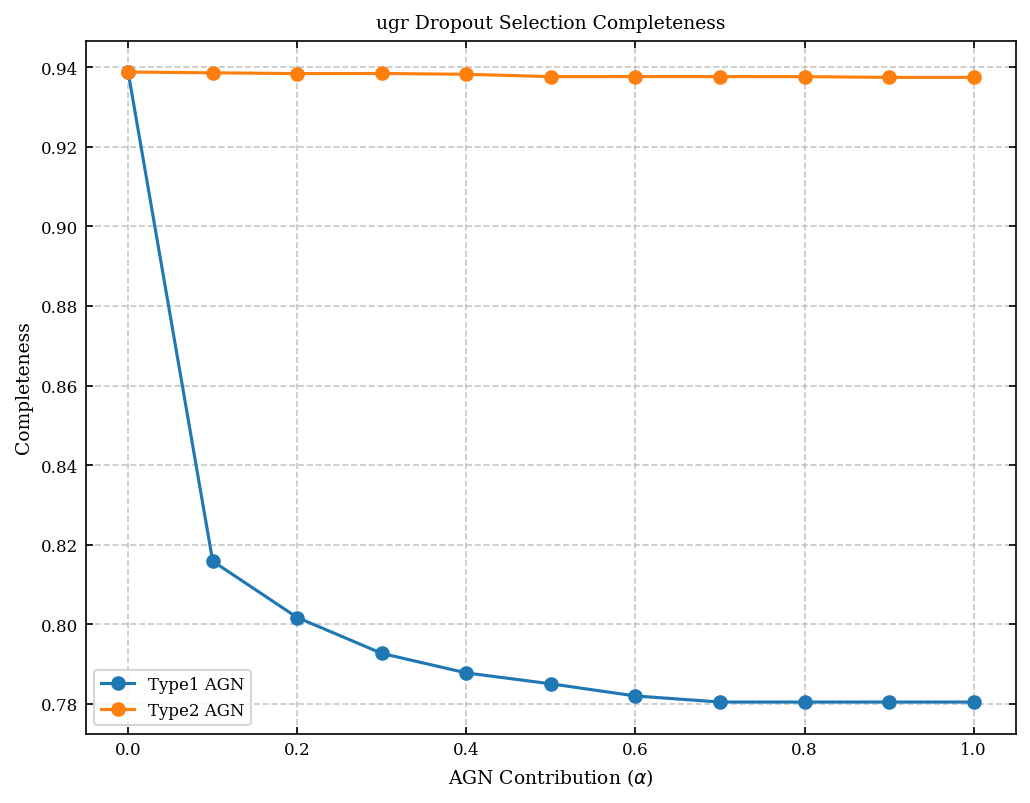

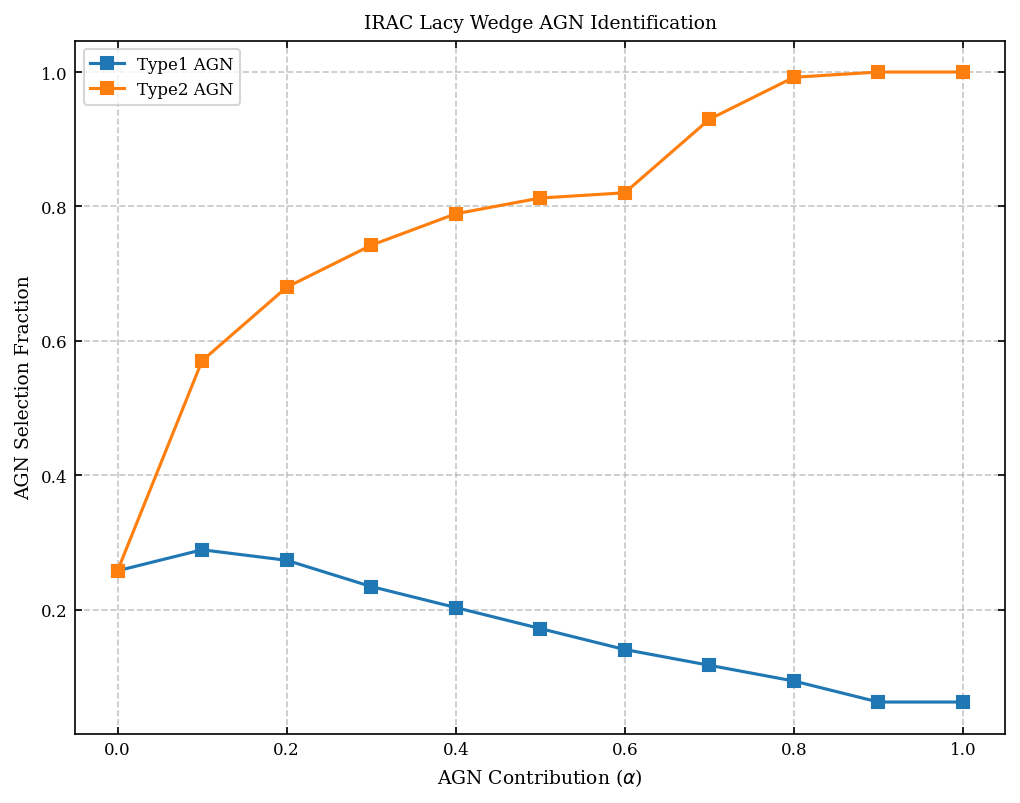

In [19]:
# 1. ugr Dropout Completeness (from redshift grid data)
grid_file = os.path.join(config.PROCESSED_DATA_DIR, 'ugr_completeness_grid.csv')
if os.path.exists(grid_file):
    df_grid = pd.read_csv(grid_file)
    df_comp_ugr = analysis.calculate_completeness_from_df(df_grid)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    for agn_type in df_comp_ugr['AGN_Type'].unique():
        subset = df_comp_ugr[df_comp_ugr['AGN_Type'] == agn_type]
        ax.plot(subset['Alpha'], subset['Completeness'], marker='o', label=f'{agn_type} AGN')
        
    ax.set_xlabel(r'AGN Contribution ($\alpha$)')
    ax.set_ylabel('Completeness')
    ax.set_title('ugr Dropout Selection Completeness')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_ugr_Completeness.pdf'), bbox_inches='tight')
    plt.show()

# 2. IRAC Lacy Wedge Completeness (calculated from df_results)
def calculate_irac_completeness(df):
    res = []
    for agn_type in df['AGN_Type'].unique():
        subset = df[df['AGN_Type'] == agn_type]
        for alpha in subset['Alpha'].unique():
            alpha_df = subset[subset['Alpha'] == alpha]
            in_wedge = analysis.is_in_lacy_wedge(alpha_df['f5836'], alpha_df['f8045'])
            # For IRAC, completeness is fraction identified as AGN
            completeness = np.sum(in_wedge) / len(alpha_df)
            res.append({'AGN_Type': agn_type, 'Alpha': alpha, 'Completeness': completeness})
    return pd.DataFrame(res)

df_comp_irac = calculate_irac_completeness(df_results)

fig, ax = plt.subplots(figsize=(8, 6))
for agn_type in df_comp_irac['AGN_Type'].unique():
    subset = df_comp_irac[df_comp_irac['AGN_Type'] == agn_type]
    ax.plot(subset['Alpha'], subset['Completeness'], marker='s', label=f'{agn_type} AGN')
    
ax.set_xlabel(r'AGN Contribution ($\alpha$)')
ax.set_ylabel('AGN Selection Fraction')
ax.set_title('IRAC Lacy Wedge AGN Identification')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_IRAC_Completeness.pdf'), bbox_inches='tight')
plt.show()

## 5. Statistical Tables (LaTeX Exports)

Exporting the final results to LaTeX for inclusion in the paper.

In [20]:
def calculate_uvj_offsets(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    offsets = []
    for alpha in subset['Alpha'].unique():
        alpha_df = subset[subset['Alpha'] == alpha]
        initial_df = subset[subset['Alpha'] == 0.0]
        
        vj_alpha = alpha_df['V-J'].values
        uv_alpha = alpha_df['U-V'].values
        vj_init = initial_df['V-J'].values
        uv_init = initial_df['U-V'].values
        
        mean_offset = analysis.calculate_mean_vector_offset(vj_alpha, uv_alpha, vj_init, uv_init)
        offsets.append({'Alpha': alpha, 'Mean_Offset': mean_offset})
    return pd.DataFrame(offsets)

off1 = calculate_uvj_offsets(df_results, 'Type1')
off2 = calculate_uvj_offsets(df_results, 'Type2')

table_df = pd.DataFrame({
    r'AGN Contribution ($\\alpha$)': [f"{int(a*100)}\\%" for a in alphas],
    'Type 1 Offset (dex)': off1['Mean_Offset'].round(3),
    'Type 2 Offset (dex)': off2['Mean_Offset'].round(3)
})

display(table_df)
table_df.to_csv(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_vectoroffset.csv'), index=False)
latex_table = table_df.to_latex(index=False, caption=r"Mean vector offset for Type 1 and Type 2 AGN composites in the UVJ diagram.", label="tab:UVJ_vectoroffset")
with open(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_vectoroffset.tex'), 'w') as f:
    f.write(latex_table)

print("Exported UVJ Vector Offset table.")

,AGN Contribution ($\\alpha$),Type 1 Offset (dex),Type 2 Offset (dex)
0,0\%,0.000,0.000
1,10\%,0.090,0.000
2,20\%,0.165,0.000
3,30\%,0.229,0.001
4,40\%,0.285,0.001
5,50\%,0.335,0.001
6,60\%,0.380,0.001
7,70\%,0.420,0.002
8,80\%,0.457,0.002
9,90\%,0.491,0.002


Exported UVJ Vector Offset table.


## 6. UVJ Population Fraction Analysis

This section analyzes how AGN contamination causes galaxies to migrate between the Star-forming, Quiescent, and Dusty regions of the UVJ diagram.

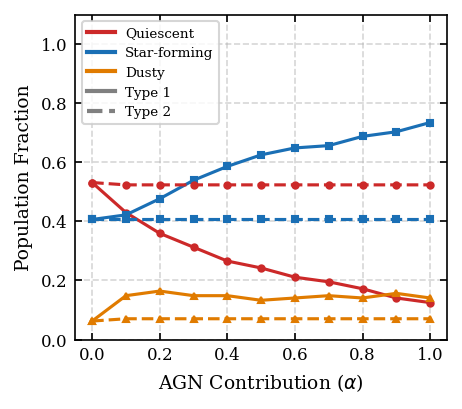

In [21]:
def calculate_uvj_fractions(df, agn_type):
    subset = df[df['AGN_Type'] == agn_type]
    alphas_sorted = sorted(subset['Alpha'].unique())
    q_fracs, sf_fracs, d_fracs = [], [], []
    for alpha in alphas_sorted:
        alpha_df = subset[subset['Alpha'] == alpha]
        classifications = analysis.classify_uvj(alpha_df['V-J'], alpha_df['U-V'])
        q, sf, d = analysis.calculate_population_fractions(classifications)
        q_fracs.append(q)
        sf_fracs.append(sf)
        d_fracs.append(d)
    return alphas_sorted, q_fracs, sf_fracs, d_fracs

fig, ax = plt.subplots(figsize=(3.15, 2.8))

pop_colors = {'Quiescent': '#CC2929', 'Star-forming': '#1A6FB5', 'Dusty': '#E07B00'}

for agn_type, ls in [('Type1', '-'), ('Type2', '--')]:
    alphas_sorted, q_fracs, sf_fracs, d_fracs = calculate_uvj_fractions(df_results, agn_type)
    type_label = 'Type 1' if agn_type == 'Type1' else 'Type 2'
    ax.plot(alphas_sorted, q_fracs,  color=pop_colors['Quiescent'],    linestyle=ls, marker='o', markersize=3, label=f'Quiescent ({type_label})')
    ax.plot(alphas_sorted, sf_fracs, color=pop_colors['Star-forming'], linestyle=ls, marker='s', markersize=3, label=f'Star-forming ({type_label})')
    ax.plot(alphas_sorted, d_fracs,  color=pop_colors['Dusty'],        linestyle=ls, marker='^', markersize=3, label=f'Dusty ({type_label})')

ax.set_xlabel(r'AGN Contribution ($\alpha$)')
ax.set_ylabel('Population Fraction')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_ylim([0, 1.1])

# Compact legend: 3 colour entries + 2 linestyle entries
color_handles = [
    Line2D([0],[0], color=pop_colors['Quiescent'],    lw=2, label='Quiescent'),
    Line2D([0],[0], color=pop_colors['Star-forming'], lw=2, label='Star-forming'),
    Line2D([0],[0], color=pop_colors['Dusty'],        lw=2, label='Dusty'),
]
type_handles = [
    Line2D([0],[0], color='gray', lw=2, linestyle='-',  label='Type 1'),
    Line2D([0],[0], color='gray', lw=2, linestyle='--', label='Type 2'),
]
ax.legend(handles=color_handles + type_handles, fontsize=6.5, loc='upper left')

plt.tight_layout()
fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'Paper_UVJ_Fractions_Combined.pdf'), dpi=300, bbox_inches='tight')
plt.show()

## 7. Composite SED Progression (Fig 6)

Recreating Figure 6: 1D SED progression for representative Star-forming, Quiescent, and Dusty galaxies with increasing Type 1 AGN contribution.

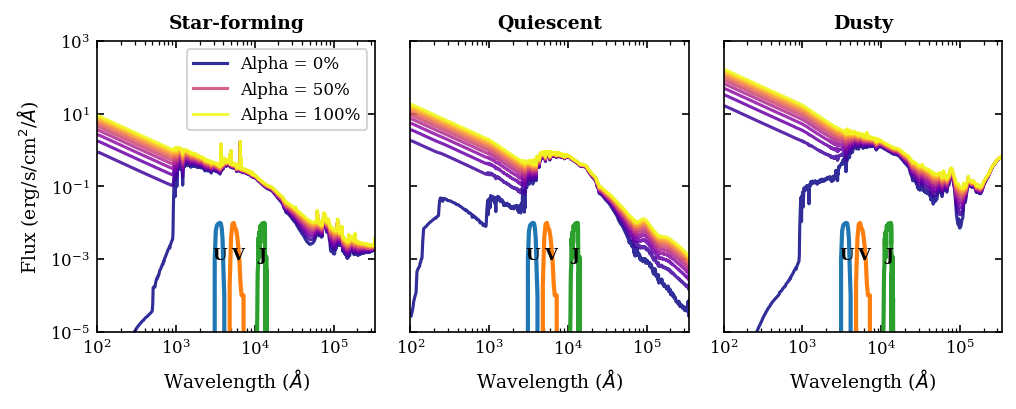

In [22]:
# Representative templates from Brown (GALSEDATLAS) set
# Star-forming: NGC_0337, Quiescent: NGC_4552, Dusty: IC_4553 (Arp 220)
rep_templates = {
    'Star-forming': 'NGC_0337',
    'Quiescent': 'NGC_4552',
    'Dusty': 'IC_4553'
}

comp_progression_data = {}

for pop_name, gal_name in rep_templates.items():
    if gal_name in brown_names:
        t_idx = brown_names.index(gal_name)
        gal_sed = brown_templates[t_idx]
        comp_progression_data[pop_name] = {}
        for alpha in alphas:
            comp_sed = composite_math.create_composite_sed(agn_type1, gal_sed, alpha)
            comp_progression_data[pop_name][alpha] = comp_sed

visualization.plot_composite_sed_progression(
    comp_progression_data, filters,
    show_title=True,
    orientation='horizontal',
    figsize=visualization.PASA_SED_WIDE,
    output_path=os.path.join(config.PROCESSED_DATA_DIR, 'CompositeSEDs_UVJ.pdf')
)
plt.show()

## 8. Observational ZFOURGE Composites (Fig 7, 8, Table 4)

This section confirms theoretical trends using observational ZFOURGE data by tracking how the average galaxy in each UVJ region evolves with increasing Type 1 AGN contribution.

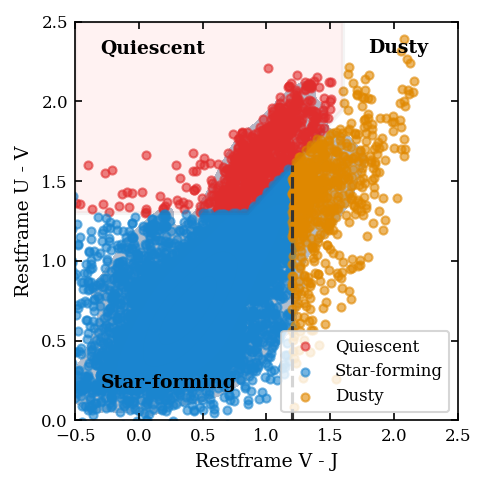

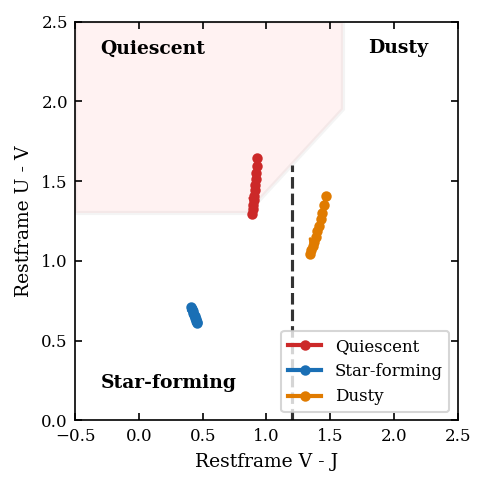

In [23]:
# Load the pre-generated observational composite data (calculated during Honours phase)
obs_csv_path = os.path.join('..\outputs', 'composite_seds', 'ZFOURGE_obsevational_composites_fluxesType1AGN.csv')
if os.path.exists(obs_csv_path):
    df_obs = pd.read_csv(obs_csv_path, index_col=0)

    # Re-classify Alpha=0 galaxies
    df_obs['Classification'] = photometry.classify_uvj(df_obs['V_0'] - df_obs['J_0'], df_obs['U_0'] - df_obs['V_0'])

    # Fig 7: UVJ Density at Alpha=0%
    uv_0 = df_obs['U_0'] - df_obs['V_0']
    vj_0 = df_obs['V_0'] - df_obs['J_0']
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    visualization.plot_uvj_diagram(vj_0, uv_0, classifications=df_obs['Classification'],
                                   show_density=True, ax=ax, title="",
                                   scatter_colors=('#E03030', '#1A85D0', '#E08800'))
    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'ZFOURGE_UVJ_Density_alpha0.pdf'), dpi=300, bbox_inches='tight')
    plt.show()

    # Fig 8: Average Region Tracks — use vibrant print-safe colours matching scatter
    regions = {0: 'Quiescent', 1: 'Star-forming', 2: 'Dusty'}
    colors  = {0: '#CC2929',   1: '#1A6FB5',       2: '#E07B00'}
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    visualization.plot_uvj_diagram([], [], ax=ax, title="")

    for cid, name in regions.items():
        sub = df_obs[df_obs['Classification'] == cid]
        if len(sub) == 0: continue
        tvj = [sub[f'V_{a}'].mean() - sub[f'J_{a}'].mean() for a in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]]
        tuv = [sub[f'U_{a}'].mean() - sub[f'V_{a}'].mean() for a in [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]]
        ax.plot(tvj, tuv, marker='o', color=colors[cid], label=name, lw=2, markersize=4)
        ax.annotate('', xy=(tvj[-1], tuv[-1]), xytext=(tvj[0], tuv[0]),
                    arrowprops=dict(arrowstyle="->", color=colors[cid], lw=1.5))
    ax.legend(loc='lower right')
    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'ZFOURGE_UVJ_RegionTracks.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print(f"Observational composite file not found at: {obs_csv_path}")

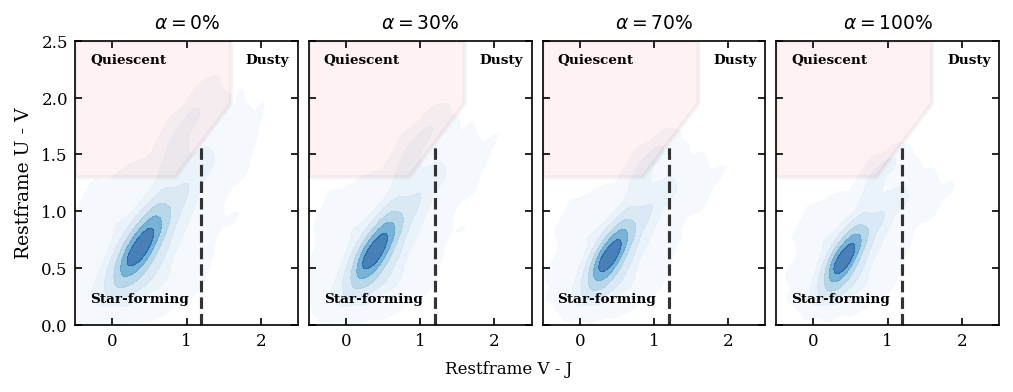

In [24]:
# --- Type 1 AGN UVJ Density Evolution (4-panel, ZFOURGE observational data) ---
alpha_cols   = [0, 30, 70, 100]
alpha_labels = [r'$\alpha=0\%$', r'$\alpha=30\%$', r'$\alpha=70\%$', r'$\alpha=100\%$']

fig, axes = plt.subplots(1, 4, figsize=(6.85, 2.5), sharex=True, sharey=True)

for ax, a, label in zip(axes, alpha_cols, alpha_labels):
    vj = df_obs[f'V_{a}'] - df_obs[f'J_{a}']
    uv = df_obs[f'U_{a}'] - df_obs[f'V_{a}']
    valid = vj.notna() & uv.notna()
    sns.kdeplot(x=vj[valid], y=uv[valid],
                fill=True, cmap='Blues', levels=7, thresh=0.02, alpha=0.75, ax=ax)
    visualization.plot_uvj_diagram([], [], ax=ax, title=label)
    for txt in ax.texts:
        txt.set_fontsize(6.5)
    ax.set_xlabel('')
    ax.set_ylabel('')

axes[0].set_ylabel('Restframe U - V')
fig.text(0.5, -0.01, 'Restframe V - J', ha='center', fontsize=8)

plt.tight_layout()
fig.subplots_adjust(wspace=0.05)
for ax in axes[1:]:
    ax.tick_params(labelleft=False)

fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_Type1_Density_Evolution.pdf'), dpi=300, bbox_inches='tight')
plt.show()

## 9. CIGALE Decomposed Population Analysis (Fig 9, 10, 11)

Final observational support: analyzing the UVJ shift of the entire ZFOURGE population when AGN light is removed via CIGALE SED decomposition.

In [ ]:
# Load CIGALE summary table
cigale_csv = os.path.join('..\datasets', 'full_zfourge_decomposed', 'zfourge_full_final.csv')
agn_frac_csv = os.path.join('..\datasets', 'full_zfourge_decomposed', 'agn_fractions.csv')
if os.path.exists(cigale_csv):
    df_cig = pd.read_csv(cigale_csv)
    z_col = 'zpk_x' if 'zpk_x' in df_cig.columns else 'zpk'

    # Attach CIGALE best-fit AGN fraction (agn.fracAGN) to each galaxy.
    # The cache is built from the per-galaxy best-model FITS headers if not present.
    if not os.path.exists(agn_frac_csv):
        from astropy.io import fits as _fits
        _rows = []
        for _gid, _field in zip(df_cig['ID'], df_cig['field']):
            _path = os.path.join('..\datasets', 'full_zfourge_decomposed',
                                 f"{_field.lower()}_best_models_fits",
                                 f"{_gid.split('_', 1)[1]}_best_model.fits")
            if os.path.exists(_path):
                _rows.append({'ID': _gid, 'fracAGN': float(_fits.getheader(_path, 1)['agn.fracAGN'])})
        pd.DataFrame(_rows).to_csv(agn_frac_csv, index=False)
    df_cig = df_cig.merge(pd.read_csv(agn_frac_csv), on='ID', how='left')

    # Only galaxies with a non-zero best-fit AGN fraction can shift when the AGN
    # is removed; galaxies with fracAGN = 0 have identical full/decomposed colours
    # and dilute the mean shift. Raise the threshold (e.g. 0.1) for a stricter cut.
    AGN_FRAC_MIN = 0.0
    df_agn = df_cig[df_cig['fracAGN'] > AGN_FRAC_MIN]
    print(f"AGN-hosting galaxies (fracAGN > {AGN_FRAC_MIN}): {len(df_agn)} of {len(df_cig)}")

    # Fig 9: Full + decomposed scatter with bold per-region mean shift arrows
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    visualization.plot_uvj_diagram([], [], ax=ax, title="")

    ax.scatter(df_agn['VJ_Full'],       df_agn['UV_Full'],       c='#444444',   s=5, alpha=0.15, label='Full galaxy',     zorder=3)
    ax.scatter(df_agn['VJ_Decomposed'], df_agn['UV_Decomposed'], c='darkorange', s=5, alpha=0.25, label='Decomposed host', zorder=3)

    # Bold mean vectors per UVJ region (classified by full-galaxy position)
    classifications_full = photometry.classify_uvj(df_agn['VJ_Full'], df_agn['UV_Full'])
    region_colors = {0: '#CC2929', 1: '#1A6FB5', 2: '#E07B00'}
    region_names  = {0: 'Quiescent', 1: 'Star-forming', 2: 'Dusty'}
    for cid in [0, 1, 2]:
        mask = classifications_full == cid
        if mask.sum() < 3: continue
        mvj_f = df_agn.loc[mask, 'VJ_Full'].mean()
        muv_f = df_agn.loc[mask, 'UV_Full'].mean()
        mvj_d = df_agn.loc[mask, 'VJ_Decomposed'].mean()
        muv_d = df_agn.loc[mask, 'UV_Decomposed'].mean()
        print(f"{region_names[cid]}: shift = ({mvj_d - mvj_f:+.3f}, {muv_d - muv_f:+.3f})  n={mask.sum()}")
        ax.annotate('', xy=(mvj_d, muv_d), xytext=(mvj_f, muv_f),
                    arrowprops=dict(arrowstyle='->', color=region_colors[cid], lw=2.5))
        ax.plot(mvj_f, muv_f, 'o', color=region_colors[cid], markersize=7, zorder=6)
        ax.plot(mvj_d, muv_d, '^', color=region_colors[cid], markersize=7, zorder=6,
                label=f'{region_names[cid]} mean shift')

    ax.legend(loc='upper left', fontsize=7)
    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_CIGALE_FullDecomp_Vectors.pdf'), dpi=300, bbox_inches='tight')
    plt.show()

    # Fig 11: Redshift Divergence — mean full vs decomposed positions per redshift bin
    bins = [[0, 0.5], [0.5, 1.0], [1.0, 1.5], [1.5, 2.0], [2.0, 2.5], [2.5, 3.5]]
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    cmap = plt.cm.viridis
    for i, (z_min, z_max) in enumerate(bins):
        sub = df_agn[(df_agn[z_col] >= z_min) & (df_agn[z_col] < z_max)]
        if len(sub) < 5: continue
        mvj_f, muv_f = sub['VJ_Full'].mean(), sub['UV_Full'].mean()
        mvj_d, muv_d = sub['VJ_Decomposed'].mean(), sub['UV_Decomposed'].mean()
        c = cmap(i / len(bins))
        ax.plot(mvj_f, muv_f, 'o', color=c, markersize=6, label=f'z=[{z_min},{z_max}]')
        ax.plot(mvj_d, muv_d, '^', color=c, markersize=6)
        ax.annotate('', xy=(mvj_d, muv_d), xytext=(mvj_f, muv_f),
                    arrowprops=dict(arrowstyle="->", color=c, lw=2, alpha=0.7))
    ax.legend(loc='lower right', title="Redshift bins", title_fontsize=7)
    plt.tight_layout()
    fig.savefig(os.path.join(config.PROCESSED_DATA_DIR, 'UVJ_agn_evolution_CIGALE_ZFOURGE_comparison_redshift.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("CIGALE summary table not found.")

### 9b. Decomposition shift as a function of AGN fraction

Diagnostic figures splitting the CIGALE decomposition shift into disjoint `fracAGN` bins (the CIGALE grid is discrete: 0, 0.01, 0.1, ..., 0.9, 0.99). Each bin is an independent sample, so the growth of the UVJ shift with AGN contribution is directly readable. Outputs are saved to `outputs/fracAGN_diagnostics/`. Requires the section 9 cell above to have run (provides `df_cig` with `fracAGN` merged).

In [ ]:
# Disjoint fracAGN bins (fracAGN is a discrete CIGALE grid: 0, 0.01, 0.1, ..., 0.9, 0.99;
# edges sit between grid values so float comparison is safe)
FRAC_BINS = [(0.005, 0.15, '0.01–0.1'), (0.15, 0.35, '0.2–0.3'),
             (0.35, 0.55, '0.4–0.5'),   (0.55, 1.00, '0.6–0.99')]
frac_out_dir = os.path.join(config.PROCESSED_DATA_DIR, 'fracAGN_diagnostics')
os.makedirs(frac_out_dir, exist_ok=True)

region_colors = {0: '#CC2929', 1: '#1A6FB5', 2: '#E07B00'}
region_names  = {0: 'Quiescent', 1: 'Star-forming', 2: 'Dusty'}

def region_mean_shifts(d, min_n=3):
    """Mean full/decomposed UVJ positions per region (classified on full colours)."""
    cls = photometry.classify_uvj(d['VJ_Full'], d['UV_Full'])
    out = {}
    for cid in [0, 1, 2]:
        m = cls == cid
        if m.sum() < min_n: continue
        out[cid] = (d.loc[m, 'VJ_Full'].mean(),       d.loc[m, 'UV_Full'].mean(),
                    d.loc[m, 'VJ_Decomposed'].mean(), d.loc[m, 'UV_Decomposed'].mean(),
                    int(m.sum()))
    return out

# Fig A: 2x2 UVJ grid — scatter + per-region mean shift arrows for each fracAGN bin
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
print(f"{'Bin':>10} {'Region':>14} {'dVJ':>8} {'dUV':>8} {'|shift|':>8} {'n':>6}")
for ax, (lo, hi, label) in zip(axes.flat, FRAC_BINS):
    d = df_cig[(df_cig['fracAGN'] > lo) & (df_cig['fracAGN'] <= hi)]
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    ax.scatter(d['VJ_Full'],       d['UV_Full'],       c='#444444',    s=4, alpha=0.15, zorder=3)
    ax.scatter(d['VJ_Decomposed'], d['UV_Decomposed'], c='darkorange', s=4, alpha=0.25, zorder=3)
    for cid, (vj_f, uv_f, vj_d, uv_d, n) in region_mean_shifts(d).items():
        print(f"{label:>10} {region_names[cid]:>14} {vj_d - vj_f:>+8.3f} {uv_d - uv_f:>+8.3f} "
              f"{np.hypot(vj_d - vj_f, uv_d - uv_f):>8.3f} {n:>6}")
        ax.annotate('', xy=(vj_d, uv_d), xytext=(vj_f, uv_f),
                    arrowprops=dict(arrowstyle='->', color=region_colors[cid], lw=2.5))
        ax.plot(vj_f, uv_f, 'o', color=region_colors[cid], markersize=6, zorder=6)
        ax.plot(vj_d, uv_d, '^', color=region_colors[cid], markersize=6, zorder=6)
    ax.set_title(f'fracAGN {label}  (n={len(d)})', fontsize=8)
    for txt in ax.texts:
        txt.set_fontsize(6.5)

legend_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#444444', markersize=5, label='Full galaxy'),
                  Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=5, label='Decomposed host')] + \
                 [Line2D([0], [0], color=region_colors[cid], lw=2, label=region_names[cid]) for cid in [0, 1, 2]]
axes.flat[0].legend(handles=legend_handles, loc='lower right', fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_FullDecomp_Vectors_fracAGN_bins.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Fig B: single-axis summary — per-region mean shift arrows for all bins on one diagram
fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
visualization.plot_uvj_diagram([], [], ax=ax, title="")
bin_alphas = np.linspace(0.35, 1.0, len(FRAC_BINS))
bin_lws    = np.linspace(1.0, 2.8, len(FRAC_BINS))
for i, (lo, hi, label) in enumerate(FRAC_BINS):
    d = df_cig[(df_cig['fracAGN'] > lo) & (df_cig['fracAGN'] <= hi)]
    for cid, (vj_f, uv_f, vj_d, uv_d, n) in region_mean_shifts(d, min_n=20).items():
        ax.annotate('', xy=(vj_d, uv_d), xytext=(vj_f, uv_f),
                    arrowprops=dict(arrowstyle='->', color=region_colors[cid],
                                    lw=bin_lws[i], alpha=bin_alphas[i]))
        ax.plot(vj_d, uv_d, '^', color=region_colors[cid], markersize=5,
                alpha=bin_alphas[i], zorder=6)
legend_handles = [Line2D([0], [0], color=region_colors[cid], lw=2, label=region_names[cid]) for cid in [0, 1, 2]] + \
                 [Line2D([0], [0], color='gray', lw=bin_lws[i], alpha=bin_alphas[i], label=f'fracAGN {b[2]}')
                  for i, b in enumerate(FRAC_BINS)]
ax.legend(handles=legend_handles, loc='upper left', fontsize=6)
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_FullDecomp_Vectors_fracAGN_summary.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Fig C: Redshift divergence within each fracAGN bin (2x2 grid, Fig 8 style per panel)
z_bins = [[0, 0.5], [0.5, 1.0], [1.0, 1.5], [1.5, 2.0], [2.0, 2.5], [2.5, 3.5]]
cmap = plt.cm.viridis

fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, (lo, hi, label) in zip(axes.flat, FRAC_BINS):
    d = df_cig[(df_cig['fracAGN'] > lo) & (df_cig['fracAGN'] <= hi)]
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    for i, (z_min, z_max) in enumerate(z_bins):
        sub = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
        if len(sub) < 5: continue
        mvj_f, muv_f = sub['VJ_Full'].mean(), sub['UV_Full'].mean()
        mvj_d, muv_d = sub['VJ_Decomposed'].mean(), sub['UV_Decomposed'].mean()
        c = cmap(i / len(z_bins))
        ax.plot(mvj_f, muv_f, 'o', color=c, markersize=6, label=f'z=[{z_min},{z_max}]')
        ax.plot(mvj_d, muv_d, '^', color=c, markersize=6)
        ax.annotate('', xy=(mvj_d, muv_d), xytext=(mvj_f, muv_f),
                    arrowprops=dict(arrowstyle="->", color=c, lw=2, alpha=0.7))
    ax.set_title(f'fracAGN {label}  (n={len(d)})', fontsize=8)
    for txt in ax.texts:
        txt.set_fontsize(6.5)

axes.flat[0].legend(loc='lower right', title="Redshift bins", title_fontsize=6, fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_redshift_fracAGN_bins.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Cumulative fracAGN cutoffs: what the paper figure looks like at each candidate cut.
# Panels overlap in membership (every galaxy in >0.5 is also in >0), unlike the
# disjoint bins above — use these to choose AGN_FRAC_MIN for the paper figures.
FRAC_CUTS = [0.0, 0.1, 0.2, 0.5]

# Fig D: 2x2 UVJ grid — scatter + per-region mean shift arrows for each cutoff
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
print(f"{'Cut':>10} {'Region':>14} {'dVJ':>8} {'dUV':>8} {'|shift|':>8} {'n':>6}")
for ax, cut in zip(axes.flat, FRAC_CUTS):
    d = df_cig[df_cig['fracAGN'] > cut]
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    ax.scatter(d['VJ_Full'],       d['UV_Full'],       c='#444444',    s=4, alpha=0.15, zorder=3)
    ax.scatter(d['VJ_Decomposed'], d['UV_Decomposed'], c='darkorange', s=4, alpha=0.25, zorder=3)
    for cid, (vj_f, uv_f, vj_d, uv_d, n) in region_mean_shifts(d).items():
        print(f"{'>' + str(cut):>10} {region_names[cid]:>14} {vj_d - vj_f:>+8.3f} {uv_d - uv_f:>+8.3f} "
              f"{np.hypot(vj_d - vj_f, uv_d - uv_f):>8.3f} {n:>6}")
        ax.annotate('', xy=(vj_d, uv_d), xytext=(vj_f, uv_f),
                    arrowprops=dict(arrowstyle='->', color=region_colors[cid], lw=2.5))
        ax.plot(vj_f, uv_f, 'o', color=region_colors[cid], markersize=6, zorder=6)
        ax.plot(vj_d, uv_d, '^', color=region_colors[cid], markersize=6, zorder=6)
    ax.set_title(f'fracAGN > {cut}  (n={len(d)})', fontsize=8)
    for txt in ax.texts:
        txt.set_fontsize(6.5)

legend_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#444444', markersize=5, label='Full galaxy'),
                  Line2D([0], [0], marker='o', color='w', markerfacecolor='darkorange', markersize=5, label='Decomposed host')] + \
                 [Line2D([0], [0], color=region_colors[cid], lw=2, label=region_names[cid]) for cid in [0, 1, 2]]
axes.flat[0].legend(handles=legend_handles, loc='lower right', fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_FullDecomp_Vectors_fracAGN_cuts.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Fig E: single-axis summary — per-region mean shift arrows for all cutoffs
fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
visualization.plot_uvj_diagram([], [], ax=ax, title="")
cut_alphas = np.linspace(0.35, 1.0, len(FRAC_CUTS))
cut_lws    = np.linspace(1.0, 2.8, len(FRAC_CUTS))
for i, cut in enumerate(FRAC_CUTS):
    d = df_cig[df_cig['fracAGN'] > cut]
    for cid, (vj_f, uv_f, vj_d, uv_d, n) in region_mean_shifts(d, min_n=20).items():
        ax.annotate('', xy=(vj_d, uv_d), xytext=(vj_f, uv_f),
                    arrowprops=dict(arrowstyle='->', color=region_colors[cid],
                                    lw=cut_lws[i], alpha=cut_alphas[i]))
        ax.plot(vj_d, uv_d, '^', color=region_colors[cid], markersize=5,
                alpha=cut_alphas[i], zorder=6)
legend_handles = [Line2D([0], [0], color=region_colors[cid], lw=2, label=region_names[cid]) for cid in [0, 1, 2]] + \
                 [Line2D([0], [0], color='gray', lw=cut_lws[i], alpha=cut_alphas[i], label=f'fracAGN > {c}')
                  for i, c in enumerate(FRAC_CUTS)]
ax.legend(handles=legend_handles, loc='upper left', fontsize=6)
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_FullDecomp_Vectors_fracAGN_cuts_summary.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Fig F: redshift divergence at each cutoff (2x2 grid, Fig 8 style per panel)
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, cut in zip(axes.flat, FRAC_CUTS):
    d = df_cig[df_cig['fracAGN'] > cut]
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    for i, (z_min, z_max) in enumerate(z_bins):
        sub = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
        if len(sub) < 5: continue
        mvj_f, muv_f = sub['VJ_Full'].mean(), sub['UV_Full'].mean()
        mvj_d, muv_d = sub['VJ_Decomposed'].mean(), sub['UV_Decomposed'].mean()
        c = cmap(i / len(z_bins))
        ax.plot(mvj_f, muv_f, 'o', color=c, markersize=6, label=f'z=[{z_min},{z_max}]')
        ax.plot(mvj_d, muv_d, '^', color=c, markersize=6)
        ax.annotate('', xy=(mvj_d, muv_d), xytext=(mvj_f, muv_f),
                    arrowprops=dict(arrowstyle="->", color=c, lw=2, alpha=0.7))
    ax.set_title(f'fracAGN > {cut}  (n={len(d)})', fontsize=8)
    for txt in ax.texts:
        txt.set_fontsize(6.5)

axes.flat[0].legend(loc='lower right', title="Redshift bins", title_fontsize=6, fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_redshift_fracAGN_cuts.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### 9c. Hidden quiescent galaxies revealed by decomposition

Population means dilute the decomposition effect because only a few per cent of AGN hosts change UVJ class. Tracking **per-galaxy classification transitions** (full → decomposed) exposes the systematic migration directly: AGN light disguises quiescent hosts as star-forming/dusty, and removing it moves them back — never the reverse.

In [ ]:
# Per-galaxy UVJ class transitions between full and decomposed photometry.
# Population means hide the effect: only ~5% of AGN hosts change class, but the
# migration is one-directional (SF/D -> Q; zero Q -> SF), i.e. AGN light disguises
# quiescent hosts as star-forming — the systematic shift predicted by the methodology.
d = df_cig[df_cig['fracAGN'] > 0].copy()
d['cls_full'] = photometry.classify_uvj(d['VJ_Full'].values, d['UV_Full'].values)
d['cls_dec']  = photometry.classify_uvj(d['VJ_Decomposed'].values, d['UV_Decomposed'].values)

cls_names = {0: 'Q', 1: 'SF', 2: 'D'}
print('Transition matrix (rows = full, cols = decomposed):')
print(pd.crosstab(d['cls_full'].map(cls_names), d['cls_dec'].map(cls_names)))

# Fig G: migration arrows for class-changing galaxies only
transition_styles = {
    (1, 0): ('#CC2929', 'SF → Quiescent'),
    (2, 0): ('#8E44AD', 'Dusty → Quiescent'),
    (2, 1): ('#1A6FB5', 'Dusty → SF'),
    (1, 2): ('#E07B00', 'SF → Dusty'),
}
fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
visualization.plot_uvj_diagram([], [], ax=ax, title="")
for (c_from, c_to), (color, label) in transition_styles.items():
    m = (d['cls_full'] == c_from) & (d['cls_dec'] == c_to)
    for _, row in d[m].iterrows():
        ax.annotate('', xy=(row['VJ_Decomposed'], row['UV_Decomposed']),
                    xytext=(row['VJ_Full'], row['UV_Full']),
                    arrowprops=dict(arrowstyle='->', color=color, lw=0.7, alpha=0.4))
legend_handles = [Line2D([0], [0], color=c, lw=2,
                         label=f'{lab} (n={((d["cls_full"] == f) & (d["cls_dec"] == t)).sum()})')
                  for (f, t), (c, lab) in transition_styles.items()]
ax.legend(handles=legend_handles, loc='upper left', fontsize=6)
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_class_migrations.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Fig H: quiescent fraction before/after decomposition per fracAGN bin
q_full, q_dec, labels = [], [], []
for lo, hi, label in FRAC_BINS:
    b = d[(d['fracAGN'] > lo) & (d['fracAGN'] <= hi)]
    q_full.append(100 * (b['cls_full'] == 0).mean())
    q_dec.append(100 * (b['cls_dec'] == 0).mean())
    labels.append(label)

fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
x = np.arange(len(labels))
w = 0.38
ax.bar(x - w/2, q_full, w, color='#444444',    label='Full photometry')
ax.bar(x + w/2, q_dec,  w, color='darkorange', label='Decomposed host')
for xi, (qf, qd) in enumerate(zip(q_full, q_dec)):
    ax.annotate(f'+{qd - qf:.1f}', (xi + w/2, qd), textcoords='offset points',
                xytext=(0, 2), ha='center', fontsize=6)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('fracAGN bin')
ax.set_ylabel('Quiescent fraction [%]')
ax.legend(fontsize=7)
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_hidden_quiescent_fraction.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### 9d. Deeper dives into the hidden-quiescent effect

Four follow-up angles on the class-transition result of 9c (all read variables from earlier cells — run sections 2, 9, 9b and 9c first):
1. **Hidden quiescent fraction vs redshift** — when does AGN light hide the most quiescence?
2. **Theory tie-back** — observed migration arrows vs the Type 1 composite evolution tracks (decomposition should be antiparallel to increasing $\alpha$).
3. **Distance to the quiescent wedge** — the sub-threshold population moving toward the wedge without crossing.
4. **Mover properties** — fracAGN, redshift and stellar-mass distributions of reclassified galaxies.

In [ ]:
# Angle 1 — hidden quiescent fraction vs redshift: when in cosmic time does AGN
# light hide the most quiescent galaxies?
q_full_z, q_dec_z, z_mids, z_ns = [], [], [], []
for z_min, z_max in z_bins:
    b = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
    if len(b) < 20: continue
    q_full_z.append(100 * (b['cls_full'] == 0).mean())
    q_dec_z.append(100 * (b['cls_dec'] == 0).mean())
    z_mids.append(0.5 * (z_min + z_max))
    z_ns.append(len(b))

fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
ax.plot(z_mids, q_full_z, 'o-', color='#444444',    label='Full photometry')
ax.plot(z_mids, q_dec_z,  '^-', color='darkorange', label='Decomposed host')
ax.fill_between(z_mids, q_full_z, q_dec_z, color='darkorange', alpha=0.15)
for zm, qf, qd, n in zip(z_mids, q_full_z, q_dec_z, z_ns):
    ax.annotate(f'+{qd - qf:.1f}', (zm, qd), textcoords='offset points',
                xytext=(0, 4), ha='center', fontsize=6)
ax.set_xlabel('Redshift')
ax.set_ylabel('Quiescent fraction [%]')
ax.legend(fontsize=7)
print('z bin | n | Q_full% | Q_dec% | hidden pp')
for (z_min, z_max), qf, qd, n in zip(z_bins, q_full_z, q_dec_z, z_ns):
    print(f'[{z_min},{z_max}) | {n:5d} | {qf:5.1f} | {qd:5.1f} | {qd - qf:+.1f}')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_hidden_quiescent_redshift.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Angle 2 — tie-back to theory: observed decomposition arrows vs Type 1 composite
# evolution tracks (section 2). Decomposition removes AGN light, so observed arrows
# should run ANTIPARALLEL to the increasing-alpha model tracks.
# Requires df_results from section 2; skipped otherwise.
if 'df_results' in dir():
    rep_templates = {'NGC_0337': 'Star-forming host', 'NGC_4552': 'Quiescent host', 'IC_4553': 'Dusty host'}
    fig, ax = plt.subplots(figsize=visualization.PASA_SQ)
    visualization.plot_uvj_diagram([], [], ax=ax, title="")

    # Model tracks: alpha = 0 -> 1, arrowhead at high-alpha end
    for tname, tlabel in rep_templates.items():
        t = df_results[(df_results['AGN_Type'] == 'Type1') & (df_results['Template'] == tname)].sort_values('Alpha')
        ax.plot(t['V-J'], t['U-V'], '-', color='#777777', lw=1.5, zorder=4)
        ax.annotate('', xy=(t['V-J'].iloc[-1], t['U-V'].iloc[-1]),
                    xytext=(t['V-J'].iloc[-2], t['U-V'].iloc[-2]),
                    arrowprops=dict(arrowstyle='->', color='#777777', lw=1.5))
        ax.plot(t['V-J'].iloc[0], t['U-V'].iloc[0], 'o', color='#777777', markersize=5, zorder=5)

    # Observed migrations to quiescent (individual, faint) + bold mean arrows
    for (c_from, color, lab) in [(1, '#CC2929', 'SF → Q movers'), (2, '#8E44AD', 'Dusty → Q movers')]:
        m = d[(d['cls_full'] == c_from) & (d['cls_dec'] == 0)]
        if len(m) == 0: continue
        for _, row in m.iterrows():
            ax.annotate('', xy=(row['VJ_Decomposed'], row['UV_Decomposed']),
                        xytext=(row['VJ_Full'], row['UV_Full']),
                        arrowprops=dict(arrowstyle='->', color=color, lw=0.5, alpha=0.15))
        ax.annotate('', xy=(m['VJ_Decomposed'].mean(), m['UV_Decomposed'].mean()),
                    xytext=(m['VJ_Full'].mean(), m['UV_Full'].mean()),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.5))

    legend_handles = [
        Line2D([0], [0], color='#777777', lw=1.5, marker='o', markersize=4,
               label=r'Type 1 model tracks ($\alpha: 0 \to 1$)'),
        Line2D([0], [0], color='#CC2929', lw=2, label='SF → Q movers (mean)'),
        Line2D([0], [0], color='#8E44AD', lw=2, label='Dusty → Q movers (mean)'),
    ]
    ax.legend(handles=legend_handles, loc='upper left', fontsize=6)
    plt.tight_layout()
    fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_migrations_vs_theory.pdf'), dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("df_results not in memory — run section 2 first for the theory overlay.")

In [ ]:
# Angle 3 — distance to the quiescent wedge before/after decomposition.
# Many hosts move TOWARD the wedge without crossing it; counting galaxies near the
# boundary captures this sub-threshold population beyond the 293 outright movers.
Q_BOUNDARY_SEGS = [((-0.5, 1.3), (0.85, 1.3)), ((0.85, 1.3), (1.6, 1.95)), ((1.6, 1.95), (1.6, 2.5))]

def dist_to_quiescent(vj, uv, cls):
    """Distance in colour space to the quiescent wedge boundary (0 if inside)."""
    vj, uv = np.asarray(vj, float), np.asarray(uv, float)
    dists = []
    for (x1, y1), (x2, y2) in Q_BOUNDARY_SEGS:
        dx, dy = x2 - x1, y2 - y1
        t = np.clip(((vj - x1) * dx + (uv - y1) * dy) / (dx**2 + dy**2), 0, 1)
        dists.append(np.hypot(vj - (x1 + t * dx), uv - (y1 + t * dy)))
    dist = np.min(dists, axis=0)
    dist[np.asarray(cls) == 0] = 0.0
    return dist

nonq = d[d['cls_full'] != 0].copy()
nonq['dist_full'] = dist_to_quiescent(nonq['VJ_Full'], nonq['UV_Full'], nonq['cls_full'])
nonq['dist_dec']  = dist_to_quiescent(nonq['VJ_Decomposed'], nonq['UV_Decomposed'], nonq['cls_dec'])
delta = nonq['dist_dec'] - nonq['dist_full']

closer = (delta < -1e-3).sum()
farther = (delta > 1e-3).sum()
print(f"Non-quiescent (full) AGN hosts: {len(nonq)}")
print(f"  moved TOWARD the quiescent wedge: {closer} ({100*closer/len(nonq):.1f}%)")
print(f"  moved away: {farther} ({100*farther/len(nonq):.1f}%)")
for r in [0.05, 0.1, 0.2]:
    nf = (nonq['dist_full'] <= r).sum()
    nd = (nonq['dist_dec'] <= r).sum()
    print(f"  within {r} mag of wedge (incl. inside): full={nf}, decomposed={nd} ({nd-nf:+d})")

fig, axes = plt.subplots(1, 2, figsize=(6.85, 2.6))
db = np.arange(0, 1.5, 0.05)
axes[0].hist(nonq['dist_full'], bins=db, color='#444444',    alpha=0.7, label='Full photometry')
axes[0].hist(nonq['dist_dec'],  bins=db, color='darkorange', alpha=0.6, label='Decomposed host')
axes[0].axvline(0.1, color='#CC2929', ls='--', lw=1)
axes[0].set_xlabel('Distance to quiescent wedge [mag]')
axes[0].set_ylabel('N galaxies')
axes[0].legend(fontsize=6)

dbins = np.arange(-0.8, 0.81, 0.04)
axes[1].hist(delta.clip(-0.8, 0.8), bins=dbins, color='#1A6FB5', alpha=0.8)
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_xlabel(r'$\Delta$ distance (decomposed $-$ full) [mag]')
axes[1].set_ylabel('N galaxies')
axes[1].set_yscale('log')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_boundary_distance.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Angle 4 — who are the movers? fracAGN, redshift and stellar mass distributions of
# galaxies reclassified as quiescent (SF->Q or D->Q), compared against all AGN hosts.
movers = d[(d['cls_dec'] == 0) & (d['cls_full'] != 0)]
others = d[~((d['cls_dec'] == 0) & (d['cls_full'] != 0))]
print(f"Movers to quiescent: {len(movers)} of {len(d)} AGN hosts")

fig, axes = plt.subplots(1, 3, figsize=(6.85, 2.4))

# fracAGN is discrete -> normalised bar chart per value
frac_vals = sorted(d['fracAGN'].unique())
x = np.arange(len(frac_vals))
w = 0.4
mv = movers['fracAGN'].value_counts(normalize=True).reindex(frac_vals, fill_value=0)
ot = others['fracAGN'].value_counts(normalize=True).reindex(frac_vals, fill_value=0)
axes[0].bar(x - w/2, ot.values, w, color='#444444',    label='Other AGN hosts')
axes[0].bar(x + w/2, mv.values, w, color='#CC2929',    label='Movers to Q')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{v:g}' for v in frac_vals], rotation=90, fontsize=6)
axes[0].set_xlabel('fracAGN')
axes[0].set_ylabel('Fraction of subsample')

zbins_h = np.arange(0, 4.01, 0.25)
axes[1].hist(others[z_col], bins=zbins_h, density=True, color='#444444', alpha=0.7)
axes[1].hist(movers[z_col], bins=zbins_h, density=True, color='#CC2929', alpha=0.6)
axes[1].set_xlabel('Redshift')
axes[1].set_ylabel('Density')

mgood_m = movers['lmass'] > 0
mgood_o = others['lmass'] > 0
mbins = np.arange(7.5, 12.01, 0.25)
axes[2].hist(others.loc[mgood_o, 'lmass'], bins=mbins, density=True, color='#444444', alpha=0.7)
axes[2].hist(movers.loc[mgood_m, 'lmass'], bins=mbins, density=True, color='#CC2929', alpha=0.6)
axes[2].set_xlabel(r'$\log(M_*/M_\odot)$')
axes[2].set_ylabel('Density')

axes[0].legend(fontsize=6)
print(f"Movers:  median z = {movers[z_col].median():.2f}, median lmass = {movers.loc[mgood_m,'lmass'].median():.2f}, median fracAGN = {movers['fracAGN'].median():.2f}")
print(f"Others:  median z = {others[z_col].median():.2f}, median lmass = {others.loc[mgood_o,'lmass'].median():.2f}, median fracAGN = {others['fracAGN'].median():.2f}")
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_mover_properties.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### 9e. Hidden-quiescent maps in UVJ space

The bar/line charts above give the numbers; these panels show **where in colour space the fraction change happens**. Each UVJ panel contains the full AGN-host population of the bin (faint grey, full-photometry positions), red arrows tracking each recovered quiescent galaxy from its full position into the wedge, and the quiescent fraction before → after decomposition annotated in-panel. One grid across redshift (the z > 1.5 panel is the null test — no arrows, no fraction change) and one across fracAGN bins.

In [ ]:
# Hidden-quiescent maps: UVJ panels showing WHERE the fraction change comes from.
# Each panel: all AGN hosts in the bin (faint grey, full positions), red arrows for
# the movers into the quiescent wedge, and the Q fraction before -> after annotated.
def hidden_quiescent_map(ax, sub, title):
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    ax.scatter(sub['VJ_Full'], sub['UV_Full'], c='#BBBBBB', s=3, alpha=0.25, zorder=2)
    movers = sub[(sub['cls_full'] != 0) & (sub['cls_dec'] == 0)]
    for _, row in movers.iterrows():
        ax.annotate('', xy=(row['VJ_Decomposed'], row['UV_Decomposed']),
                    xytext=(row['VJ_Full'], row['UV_Full']),
                    arrowprops=dict(arrowstyle='->', color='#CC2929', lw=0.8, alpha=0.55))
    qf = 100 * (sub['cls_full'] == 0).mean()
    qd = 100 * (sub['cls_dec'] == 0).mean()
    ax.text(0.97, 0.03, f'Q: {qf:.1f}% $\\rightarrow$ {qd:.1f}%\n({qd - qf:+.1f} pp, {len(movers)} movers)',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=7,
            bbox=dict(facecolor='white', edgecolor='#CC2929', alpha=0.85, pad=2))
    ax.set_title(title, fontsize=8)
    for txt in ax.texts[:-1]:
        txt.set_fontsize(6.5)

# Map 1: across redshift (last panel combines z > 1.5 where the effect vanishes — the null test)
map_z_bins = [(0.0, 0.5), (0.5, 1.0), (1.0, 1.5), (1.5, 3.5)]
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, (z_min, z_max) in zip(axes.flat, map_z_bins):
    sub = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
    hidden_quiescent_map(ax, sub, f'z = [{z_min}, {z_max})  (n={len(sub)})')
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_hidden_quiescent_maps_redshift.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Map 2: across disjoint fracAGN bins
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, (lo, hi, label) in zip(axes.flat, FRAC_BINS):
    sub = d[(d['fracAGN'] > lo) & (d['fracAGN'] <= hi)]
    hidden_quiescent_map(ax, sub, f'fracAGN {label}  (n={len(sub)})')
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_hidden_quiescent_maps_fracAGN.pdf'), dpi=300, bbox_inches='tight')
plt.show()

### 9f. All class transitions & the dusty-region pipeline

First, the 9e map design extended to **every** class transition (coloured by type). Then the hidden-quiescent pipeline applied to the **dusty region**: before/after dusty fractions vs redshift and fracAGN, and a comparison of the fracAGN distributions of the four migration populations — testing whether the dusty-region migrations are a different AGN effect (torus-dominated reddening at high AGN contribution) from the quiescent recoveries.

In [ ]:
# All class transitions in UVJ space: same map design as 9e but with every
# migration drawn, coloured by transition type.
all_transition_styles = {
    (1, 0): ('#CC2929', 'SF → Q'),
    (2, 0): ('#8E44AD', 'D → Q'),
    (2, 1): ('#1A6FB5', 'D → SF'),
    (1, 2): ('#E07B00', 'SF → D'),
}

def all_moves_map(ax, sub, title):
    visualization.plot_uvj_diagram([], [], ax=ax, title="")
    ax.scatter(sub['VJ_Full'], sub['UV_Full'], c='#BBBBBB', s=3, alpha=0.25, zorder=2)
    n_moved = 0
    for (c_from, c_to), (color, lab) in all_transition_styles.items():
        m = sub[(sub['cls_full'] == c_from) & (sub['cls_dec'] == c_to)]
        n_moved += len(m)
        for _, row in m.iterrows():
            ax.annotate('', xy=(row['VJ_Decomposed'], row['UV_Decomposed']),
                        xytext=(row['VJ_Full'], row['UV_Full']),
                        arrowprops=dict(arrowstyle='->', color=color, lw=0.8, alpha=0.55))
    ax.text(0.97, 0.03, f'{n_moved} of {len(sub)}\nchange class',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=7,
            bbox=dict(facecolor='white', edgecolor='#888888', alpha=0.85, pad=2))
    ax.set_title(title, fontsize=8)
    for txt in ax.texts[:-1]:
        txt.set_fontsize(6.5)

transition_handles = [Line2D([0], [0], color=c, lw=2, label=lab)
                      for c, lab in all_transition_styles.values()]

# Across redshift
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, (z_min, z_max) in zip(axes.flat, map_z_bins):
    sub = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
    all_moves_map(ax, sub, f'z = [{z_min}, {z_max})  (n={len(sub)})')
axes.flat[0].legend(handles=transition_handles, loc='upper left', fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_all_transitions_maps_redshift.pdf'), dpi=300, bbox_inches='tight')
plt.show()

# Across fracAGN bins
fig, axes = plt.subplots(2, 2, figsize=(6.85, 6.0), sharex=True, sharey=True)
for ax, (lo, hi, label) in zip(axes.flat, FRAC_BINS):
    sub = d[(d['fracAGN'] > lo) & (d['fracAGN'] <= hi)]
    all_moves_map(ax, sub, f'fracAGN {label}  (n={len(sub)})')
axes.flat[0].legend(handles=transition_handles, loc='upper left', fontsize=6)
for ax in axes[0, :]: ax.set_xlabel('')
for ax in axes[:, 1]: ax.set_ylabel('')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_all_transitions_maps_fracAGN.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Dusty-region pipeline: same before/after fraction analysis as the hidden-quiescent
# one, but for the dusty region. Note the sign: the DUSTY fraction DECREASES after
# decomposition — AGN light (red torus continuum) fakes dusty colours.
fig, axes = plt.subplots(1, 2, figsize=(6.85, 2.8))

# vs redshift
d_full_z, d_dec_z, zm = [], [], []
for z_min, z_max in z_bins:
    b = d[(d[z_col] >= z_min) & (d[z_col] < z_max)]
    if len(b) < 20: continue
    d_full_z.append(100 * (b['cls_full'] == 2).mean())
    d_dec_z.append(100 * (b['cls_dec'] == 2).mean())
    zm.append(0.5 * (z_min + z_max))
axes[0].plot(zm, d_full_z, 'o-', color='#444444',    label='Full photometry')
axes[0].plot(zm, d_dec_z,  '^-', color='darkorange', label='Decomposed host')
axes[0].fill_between(zm, d_full_z, d_dec_z, color='darkorange', alpha=0.15)
for zi, (df_, dd_) in enumerate(zip(d_full_z, d_dec_z)):
    axes[0].annotate(f'{dd_ - df_:+.1f}', (zm[zi], dd_), textcoords='offset points',
                     xytext=(0, -9), ha='center', fontsize=6)
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('Dusty fraction [%]')
axes[0].legend(fontsize=6)

# vs fracAGN bin
d_full_f, d_dec_f, labels = [], [], []
for lo, hi, label in FRAC_BINS:
    b = d[(d['fracAGN'] > lo) & (d['fracAGN'] <= hi)]
    d_full_f.append(100 * (b['cls_full'] == 2).mean())
    d_dec_f.append(100 * (b['cls_dec'] == 2).mean())
    labels.append(label)
x = np.arange(len(labels))
w = 0.38
axes[1].bar(x - w/2, d_full_f, w, color='#444444',    label='Full photometry')
axes[1].bar(x + w/2, d_dec_f,  w, color='darkorange', label='Decomposed host')
for xi, (df_, dd_) in enumerate(zip(d_full_f, d_dec_f)):
    axes[1].annotate(f'{dd_ - df_:+.1f}', (xi + w/2, dd_), textcoords='offset points',
                     xytext=(0, 2), ha='center', fontsize=6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('fracAGN bin')
axes[1].set_ylabel('Dusty fraction [%]')

print('Dusty fraction, full -> decomposed:')
for (z_min, z_max), df_, dd_ in zip(z_bins, d_full_z, d_dec_z):
    print(f'  z=[{z_min},{z_max}): {df_:5.1f}% -> {dd_:5.1f}% ({dd_ - df_:+.1f} pp)')
for label, df_, dd_ in zip(labels, d_full_f, d_dec_f):
    print(f'  fracAGN {label}: {df_:5.1f}% -> {dd_:5.1f}% ({dd_ - df_:+.1f} pp)')
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_dusty_fraction_evolution.pdf'), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Dusty movers: is this a different AGN effect? Compare fracAGN distributions of the
# three migration populations. If dusty-region migrations are driven by a different
# AGN regime (e.g. torus-dominated reddening at high AGN contribution) the dusty
# leavers should cluster at much higher fracAGN than the quiescent movers.
mover_groups = {
    'SF → Q':  (d['cls_full'] == 1) & (d['cls_dec'] == 0),
    'D → Q':   (d['cls_full'] == 2) & (d['cls_dec'] == 0),
    'D → SF':  (d['cls_full'] == 2) & (d['cls_dec'] == 1),
    'SF → D':  (d['cls_full'] == 1) & (d['cls_dec'] == 2),
}
group_colors = {'SF → Q': '#CC2929', 'D → Q': '#8E44AD', 'D → SF': '#1A6FB5', 'SF → D': '#E07B00'}

frac_vals = sorted(d['fracAGN'].unique())
x = np.arange(len(frac_vals))
n_g = len(mover_groups)
w = 0.8 / n_g
fig, ax = plt.subplots(figsize=(4.5, 2.8))
print(f"{'Group':>8} {'n':>5} {'med fracAGN':>12} {'med z':>7} {'med lmass':>10}")
for gi, (gname, gmask) in enumerate(mover_groups.items()):
    g = d[gmask]
    if len(g) == 0: continue
    dist = g['fracAGN'].value_counts(normalize=True).reindex(frac_vals, fill_value=0)
    ax.bar(x + (gi - (n_g - 1) / 2) * w, dist.values, w, color=group_colors[gname],
           label=f'{gname} (n={len(g)})')
    lm = g.loc[g['lmass'] > 0, 'lmass']
    print(f"{gname:>8} {len(g):>5} {g['fracAGN'].median():>12.2f} {g[z_col].median():>7.2f} {lm.median():>10.2f}")
ax.set_xticks(x)
ax.set_xticklabels([f'{v:g}' for v in frac_vals], rotation=90, fontsize=6)
ax.set_xlabel('fracAGN')
ax.set_ylabel('Fraction of group')
ax.legend(fontsize=6)
plt.tight_layout()
fig.savefig(os.path.join(frac_out_dir, 'UVJ_CIGALE_dusty_mover_fracAGN.pdf'), dpi=300, bbox_inches='tight')
plt.show()